In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D
from PIL import Image

# process file

### mata config

In [2]:
cpu_count = 1

In [11]:
# [timestamp_ms, (tid, latency_avg_ns)*]
latency_timeline = []
file = 'trace_mutex_latency_' + str(cpu_count) + '_CPU_results.txt'
ms = -1
with open(file, 'r') as file:
    for line in file:
        if '--- Mutex Latency Averages' in line:
            ms_index = line.index('@') + 1
            ms = int(line[ms_index:line.index('ms')])
            latency_timeline.append([ms])
        if '@mutex_latency_avgs' in line:
            tid = int(line[line.index('[')+1:line.index(']')])
            latency_avg_ns = int(line[line.index(':')+2:line.index('\n')])
            latency_timeline[-1].append( (tid, latency_avg_ns) )

print(f'traced time slices={len(latency_timeline)}')
print(f'traced duration={latency_timeline[-1][0]} ms')

traced time slices=79
traced duration=169 ms


In [12]:
# key: tid, value: ([timestamps*], [latency_avgs*])
latency_avgs_timeline_by_tid = defaultdict(lambda : ([],[]))

for i in range(len(latency_timeline)):
    timestamp_ms = latency_timeline[i][0]
    for j in range(1, len(latency_timeline[i])):
        tid, latency_avg_ns = latency_timeline[i][j]
        latency_avgs_timeline_by_tid[tid][0].append(timestamp_ms)
        latency_avgs_timeline_by_tid[tid][1].append(latency_avg_ns)

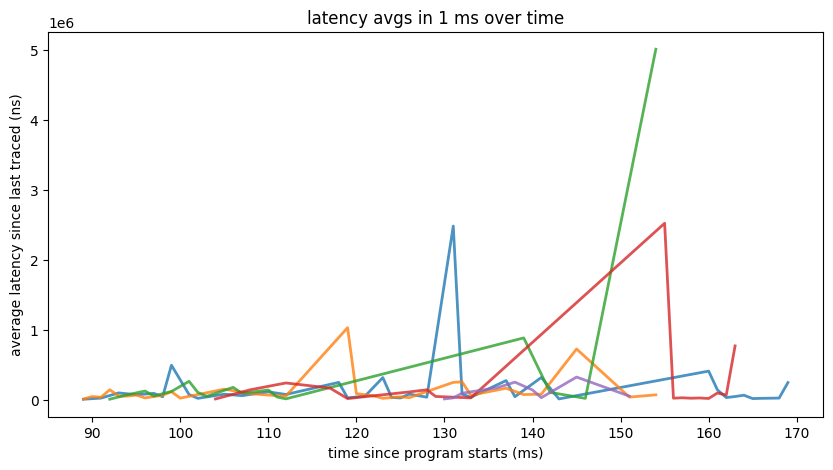

In [14]:
plt.figure(figsize=(10,5))
plt.xlabel('time since program starts (ms)')
plt.ylabel('average latency since last traced (ns)')
plt.title('latency avgs in 1 ms over time')

for tid, points in latency_avgs_timeline_by_tid.items():
    plt.plot(points[0], points[1], label=tid, alpha=0.8, lw=2)

#plt.xlim(, None)

plt.show()
plt.close()